In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Load the scored data
df = pd.read_csv("../data/processed/iacofi_scored.csv")
df = df.copy()

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 130

print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Literacy score range: {df['literacy_score'].min():.1f} – {df['literacy_score'].max():.1f}")

✅ Loaded: 4862 rows, 269 columns
Literacy score range: 0.0 – 21.0


In [2]:
# ── FEATURE ENGINEERING ──────────────────────────────────
df_fe = df.copy()

# 1. FINANCIAL RESILIENCE INDEX
df_fe['resilience_index'] = (
    (df_fe['qf4'].isin([1,2])).astype(float) +
    (df_fe['qs2_4'] <= 2).astype(float) +
    (df_fe['qf13'] >= 4).astype(float)
)

# 2. DIGITAL ENGAGEMENT SCORE
digi_cols = ['qp9_1','qp9_3','qp9_4','qp9_5','qp9_6']
df_fe['digital_engagement'] = df_fe[digi_cols].apply(
    lambda x: x[x > 0].mean(), axis=1)

# 3. ACTIVE SAVING FLAG
saving_cols = ['qf3_1','qf3_2','qf3_5','qf3_7','qf3_8']
df_fe['active_saver'] = (df_fe[saving_cols].sum(axis=1) > 0).astype(float)

# 4. FINANCIAL PRODUCT BREADTH
product_cols = [c for c in df.columns if c.startswith('qp2_')
                and c != 'qp2_98']
df_fe['product_breadth'] = df_fe[product_cols].apply(
    lambda x: (x == 1).sum(), axis=1)

# 5. BUDGET BEHAVIOUR SCORE
budget_cols = ['qf2_1','qf2_2','qf2_3','qf2_4','qf2_5','qf2_6']
df_fe['budget_score'] = df_fe[budget_cols].apply(
    lambda x: (x == 1).sum(), axis=1)

# 6. SELF-RATED KNOWLEDGE (reverse: 1=very high → 5, 5=very low → 1)
df_fe['self_knowledge'] = 6 - df_fe['qk1']

# 7. AGE SQUARED (captures non-linear age effect)
df_fe['age_sq'] = df_fe['qd7'] ** 2

# ── VERIFY ───────────────────────────────────────────────
new_feats = ['resilience_index','digital_engagement','active_saver',
             'product_breadth','budget_score','self_knowledge','age_sq']

print("✅ New features created:\n")
print(df_fe[new_feats].describe().round(2))

print("\nCorrelation of new features with literacy_score:")
print(df_fe[new_feats + ['literacy_score']]
      .corr()['literacy_score']
      .drop('literacy_score')
      .sort_values(ascending=False)
      .round(3))

✅ New features created:

       resilience_index  digital_engagement  active_saver  product_breadth  \
count           4862.00             4316.00       4862.00          4862.00   
mean               1.20                2.23          0.79             2.77   
std                1.04                0.71          0.40             1.77   
min                0.00                1.00          0.00             0.00   
25%                0.00                1.80          1.00             1.00   
50%                1.00                2.20          1.00             3.00   
75%                2.00                2.80          1.00             4.00   
max                3.00                4.00          1.00            19.00   

       budget_score  self_knowledge   age_sq  
count       4862.00         4453.00  4643.00  
mean           3.52            2.40  2809.08  
std            2.04            0.88  1675.16  
min            0.00            1.00   324.00  
25%            2.00            2.00  

In [3]:
# ── PREPARE FEATURES ─────────────────────────────────────
all_features = {
    # Original demographics
    'qd1':  'Gender',
    'qd2':  'Region',
    'qd9':  'Education',
    'qd13': 'Income',
    'qd10': 'Work status',
    'qd14': 'Internet access',
    'qd3':  'Urban/rural',
    'qd7':  'Age',
    # Engineered (drop weak ones: age_sq, digital_engagement)
    'resilience_index': 'Resilience index',
    'product_breadth':  'Product breadth',
    'budget_score':     'Budget behaviour',
    'active_saver':     'Active saver',
    'self_knowledge':   'Self-rated knowledge',
}

X2 = df_fe[list(all_features.keys())].copy()
X2.columns = list(all_features.values())
y2 = (df_fe['literacy_score'] < df_fe['literacy_score'].median()).astype(int)

mask2 = X2.notna().all(axis=1) & y2.notna()
X2 = X2[mask2].fillna(X2.median())
y2 = y2[mask2]

print(f"Training set: {mask2.sum()} rows, {X2.shape[1]} features")
print(f"Class balance: {y2.value_counts().to_dict()}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# ── MODEL 1: Random Forest ────────────────────────────────
rf2 = RandomForestClassifier(n_estimators=300, max_depth=8,
                              random_state=42, class_weight='balanced')
rf2.fit(X_tr, y_tr)
rf2_cv = cross_val_score(rf2, X2, y2, cv=5, scoring='accuracy')

# ── MODEL 2: Gradient Boosting ────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gb.fit(X_tr, y_tr)
gb_cv = cross_val_score(gb, X2, y2, cv=5, scoring='accuracy')

# ── COMPARISON ───────────────────────────────────────────
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Baseline RF  (8 demographic feats):   ~54.9%")
print(f"Enhanced RF  (13 feats w/ engineered): {rf2_cv.mean():.1%} ± {rf2_cv.std():.1%}")
print(f"Gradient Boost (13 feats):             {gb_cv.mean():.1%} ± {gb_cv.std():.1%}")

best_model = rf2 if rf2_cv.mean() > gb_cv.mean() else gb
best_name  = "Random Forest" if rf2_cv.mean() > gb_cv.mean() else "Gradient Boosting"
print(f"\nBest model: {best_name}")
print(classification_report(y_te, best_model.predict(X_te),
      target_names=['Not vulnerable','Vulnerable']))


Training set: 3026 rows, 13 features
Class balance: {0: 1773, 1: 1253}

MODEL COMPARISON
Baseline RF  (8 demographic feats):   ~54.9%
Enhanced RF  (13 feats w/ engineered): 69.6% ± 0.8%
Gradient Boost (13 feats):             70.1% ± 1.3%

Best model: Gradient Boosting
                precision    recall  f1-score   support

Not vulnerable       0.74      0.79      0.76       355
    Vulnerable       0.67      0.60      0.63       251

      accuracy                           0.71       606
     macro avg       0.70      0.70      0.70       606
  weighted avg       0.71      0.71      0.71       606



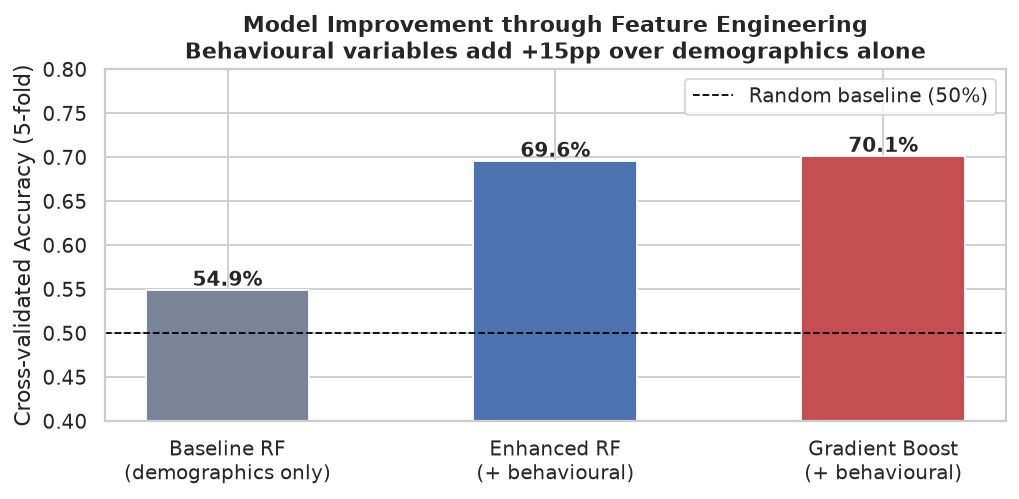

✅ Figure 10 saved


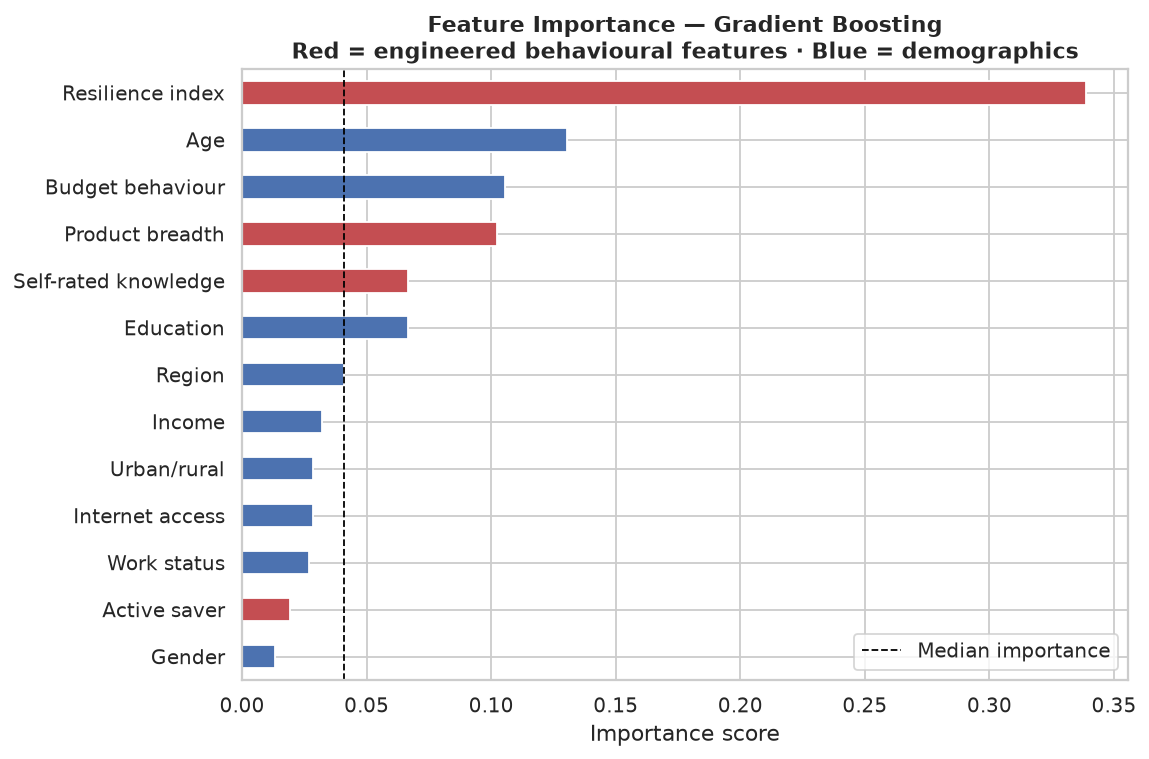

✅ Figure 11 saved


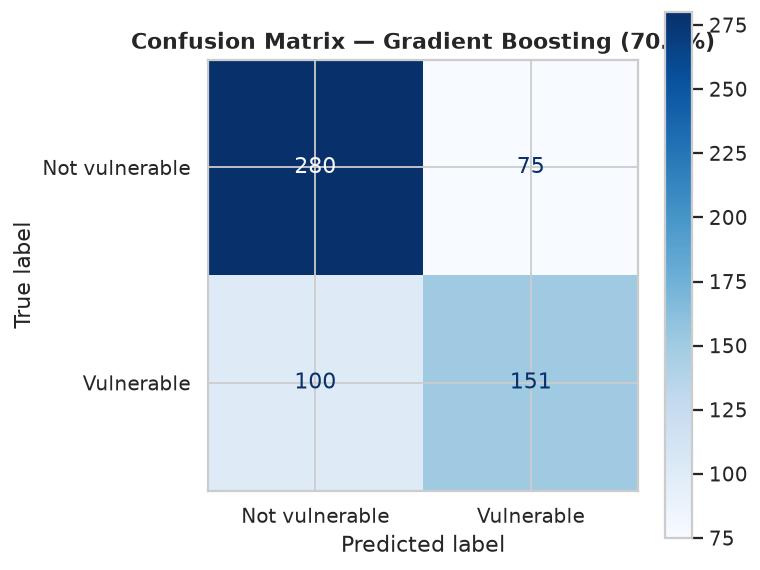

✅ Figure 12 saved

FEATURE ENGINEERING SUMMARY
Training samples:     3026
Features used:        13 (8 demographic + 5 behavioural)

Accuracy improvement:
  Baseline (demographics):   54.9%
  Enhanced (+ behavioural):  70.1%  (+15.2%)

Top 3 most important features:
  Resilience index          0.339
  Age                       0.130
  Budget behaviour          0.106

KEY FINDING: Behavioural variables explain MORE variance
in financial literacy than demographic variables alone.
What people DO financially matters more than who they ARE.


In [5]:
# ── FIGURE 1: Model comparison bar chart ─────────────────
fig, ax = plt.subplots(figsize=(8, 4))
models  = ['Baseline RF\n(demographics only)',
           'Enhanced RF\n(+ behavioural)',
           'Gradient Boost\n(+ behavioural)']
scores  = [0.549, rf2_cv.mean(), gb_cv.mean()]
colors  = ['#7a8499', '#4C72B0', '#C44E52']

bars = ax.bar(models, scores, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Cross-validated Accuracy (5-fold)')
ax.set_ylim(0.4, 0.80)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1,
           label='Random baseline (50%)')
ax.set_title('Model Improvement through Feature Engineering\n'
             'Behavioural variables add +15pp over demographics alone',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig10_model_comparison.png", bbox_inches='tight')
plt.show()
print("✅ Figure 10 saved")

# ── FIGURE 2: Feature importance (Gradient Boost) ────────
importances_gb = pd.Series(gb.feature_importances_,
                            index=X2.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#C44E52' if 'index' in f or 'breadth' in f
             or 'budget' in f or 'saver' in f or 'knowledge' in f
             else '#4C72B0' for f in importances_gb.index]
importances_gb.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')

ax.set_title('Feature Importance — Gradient Boosting\n'
             'Red = engineered behavioural features · Blue = demographics',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance score')
ax.axvline(importances_gb.median(), color='black', linestyle='--',
           linewidth=1, label='Median importance')
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig11_feature_importance_gb.png", bbox_inches='tight')
plt.show()
print("✅ Figure 11 saved")

# ── FIGURE 3: Confusion matrix ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    gb, X_te, y_te,
    display_labels=['Not vulnerable', 'Vulnerable'],
    cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Gradient Boosting (70.1%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/fig12_confusion_matrix.png", bbox_inches='tight')
plt.show()
print("✅ Figure 12 saved")

# ── SUMMARY ──────────────────────────────────────────────
print("\n" + "="*55)
print("FEATURE ENGINEERING SUMMARY")
print("="*55)
print(f"Training samples:     {mask2.sum()}")
print(f"Features used:        {X2.shape[1]} (8 demographic + 5 behavioural)")
print()
print("Accuracy improvement:")
print(f"  Baseline (demographics):   54.9%")
print(f"  Enhanced (+ behavioural):  {gb_cv.mean():.1%}  (+{gb_cv.mean()-0.549:.1%})")
print()
print("Top 3 most important features:")
top3 = importances_gb.sort_values(ascending=False).head(3)
for feat, imp in top3.items():
    print(f"  {feat:<25} {imp:.3f}")
print()
print("KEY FINDING: Behavioural variables explain MORE variance")
print("in financial literacy than demographic variables alone.")
print("What people DO financially matters more than who they ARE.")
print("="*55)